<a href="https://colab.research.google.com/github/eshikaalam/SupervisedCode/blob/main/VGG19IntegratedFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
# ===============================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install packages
# ===============================
!pip install torch torchvision scikit-learn seaborn

In [ ]:
# Imports
# ===============================
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vgg19

from sklearn.metrics import confusion_matrix, f1_score

In [ ]:
# Dataset Path
# ===============================
DATA_PATH = "/content/drive/MyDrive/AAV data/images/100mV/4s_segment_trans/train_val_photos"


In [ ]:
# Augmentations
# ===============================
weak_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

strong_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.RandomAffine(15),
    transforms.ToTensor()
])


In [ ]:
# FixMatch Dataset
# ===============================
class FixMatchDataset(Dataset):

    def __init__(self, root, weak_transform, strong_transform):

        self.dataset = ImageFolder(root)
        self.weak = weak_transform
        self.strong = strong_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        img_path, label = self.dataset.samples[idx]

        image = Image.open(img_path).convert("RGB")

        weak_img = self.weak(image)
        strong_img = self.strong(image)

        return weak_img, strong_img, label

In [ ]:
# Dataset Split
# ===============================
dataset = FixMatchDataset(DATA_PATH, weak_transform, strong_transform)

indices = list(range(len(dataset)))
random.shuffle(indices)

labeled_ratio = 0.2
labeled_count = int(len(indices)*labeled_ratio)

labeled_idx = indices[:labeled_count]
unlabeled_idx = indices[labeled_count:]

labeled_dataset = torch.utils.data.Subset(dataset, labeled_idx)
unlabeled_dataset = torch.utils.data.Subset(dataset, unlabeled_idx)

val_size = int(0.1 * len(labeled_dataset))
test_size = int(0.2 * len(labeled_dataset))
train_size = len(labeled_dataset) - val_size - test_size

train_labeled_dataset, val_dataset, test_dataset = random_split(
    labeled_dataset, [train_size, val_size, test_size]
)

In [ ]:
# DataLoaders
# ===============================
labeled_loader = DataLoader(train_labeled_dataset,batch_size=8,shuffle=True)
unlabeled_loader = DataLoader(unlabeled_dataset,batch_size=32,shuffle=True)

val_loader = DataLoader(val_dataset,batch_size=8)
test_loader = DataLoader(test_dataset,batch_size=8)

In [ ]:
# VGG19 Integrated FM Model
# ===============================
class VGG19_FM(nn.Module):

    def __init__(self,num_classes=3):

        super().__init__()

        base_model = vgg19(pretrained=True)

        # VGG19 feature extractor
        self.features = base_model.features

        # Feature Module (FM)
        self.feature_module = nn.Sequential(

            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((7,7))
        )

        # classifier
        self.classifier = nn.Sequential(

            nn.Linear(512*7*7,4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096,1024),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(1024,num_classes)
        )

    def forward(self,x):

        x = self.features(x)

        x = self.feature_module(x)

        x = torch.flatten(x,1)

        x = self.classifier(x)

        return x


In [ ]:
# Device
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VGG19_FM(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=3e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 75.7MB/s]


In [ ]:
# Validation Function
# ===============================
def evaluate(model,loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for x,_,y in loader:

            x,y = x.to(device),y.to(device)

            outputs = model(x)

            loss = criterion(outputs,y)

            preds = torch.argmax(outputs,1)

            correct += (preds==y).sum().item()

            total += y.size(0)

            total_loss += loss.item()

    acc = 100*correct/total

    return total_loss/len(loader),acc

In [ ]:
# FixMatch Training
# ===============================
train_losses=[]
val_losses=[]

train_accs=[]
val_accs=[]

def train_fixmatch(model,epochs=30):

    lambda_u=1
    threshold=0.95

    for epoch in range(epochs):

        model.train()

        labeled_iter = iter(labeled_loader)
        unlabeled_iter = iter(unlabeled_loader)

        running_loss=0
        correct=0
        total=0

        for step in range(len(unlabeled_loader)):

            try:
                x_l,_,y_l = next(labeled_iter)
            except:
                labeled_iter = iter(labeled_loader)
                x_l,_,y_l = next(labeled_iter)

            try:
                x_u_w,x_u_s,_ = next(unlabeled_iter)
            except:
                unlabeled_iter = iter(unlabeled_loader)
                x_u_w,x_u_s,_ = next(unlabeled_iter)

            x_l,y_l = x_l.to(device),y_l.to(device)
            x_u_w,x_u_s = x_u_w.to(device),x_u_s.to(device)

            optimizer.zero_grad()

            logits_l = model(x_l)

            Ls = criterion(logits_l,y_l)

            preds = torch.argmax(logits_l,1)

            correct += (preds==y_l).sum().item()

            total += y_l.size(0)

            with torch.no_grad():

                logits_u_w = model(x_u_w)

                probs = torch.softmax(logits_u_w,1)

                max_probs,pseudo_labels = torch.max(probs,1)

                mask = max_probs.ge(threshold).float()

            logits_u_s = model(x_u_s)

            Lu = (criterion(logits_u_s,pseudo_labels)*mask).mean()

            loss = Ls + lambda_u*Lu

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss/len(unlabeled_loader)
        train_acc = 100*correct/total

        val_loss,val_acc = evaluate(model,val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} TrainLoss:{train_loss:.3f} ValAcc:{val_acc:.2f}")


In [ ]:
# Train
# ===============================
train_fixmatch(model,epochs=30)


Epoch 1/30 TrainLoss:2.315 ValAcc:15.38
Epoch 2/30 TrainLoss:1.526 ValAcc:61.54
Epoch 3/30 TrainLoss:1.254 ValAcc:23.08
Epoch 4/30 TrainLoss:1.106 ValAcc:69.23
Epoch 5/30 TrainLoss:1.231 ValAcc:38.46
Epoch 6/30 TrainLoss:1.076 ValAcc:23.08
Epoch 7/30 TrainLoss:0.955 ValAcc:23.08
Epoch 8/30 TrainLoss:0.988 ValAcc:38.46
Epoch 9/30 TrainLoss:0.894 ValAcc:61.54
Epoch 10/30 TrainLoss:0.854 ValAcc:61.54
Epoch 11/30 TrainLoss:0.783 ValAcc:61.54
Epoch 12/30 TrainLoss:0.880 ValAcc:46.15
Epoch 13/30 TrainLoss:0.766 ValAcc:53.85
Epoch 14/30 TrainLoss:0.666 ValAcc:30.77
Epoch 15/30 TrainLoss:0.700 ValAcc:53.85
Epoch 16/30 TrainLoss:0.729 ValAcc:46.15
Epoch 17/30 TrainLoss:0.855 ValAcc:61.54
Epoch 18/30 TrainLoss:0.575 ValAcc:61.54
Epoch 19/30 TrainLoss:0.727 ValAcc:46.15
Epoch 20/30 TrainLoss:0.635 ValAcc:46.15
Epoch 21/30 TrainLoss:0.815 ValAcc:53.85
Epoch 22/30 TrainLoss:0.639 ValAcc:61.54
Epoch 23/30 TrainLoss:0.728 ValAcc:61.54
Epoch 24/30 TrainLoss:0.749 ValAcc:53.85
Epoch 25/30 TrainLoss:0.5

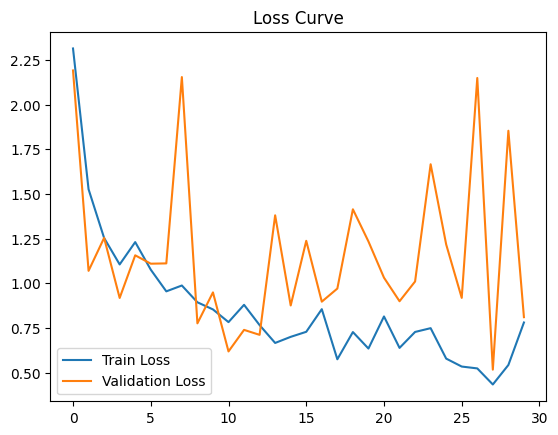

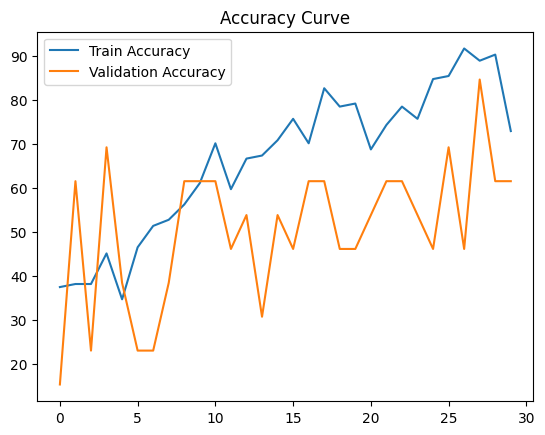

In [ ]:
# Training Curves
# ===============================
plt.figure()
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs,label="Train Accuracy")
plt.plot(val_accs,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [ ]:
# Test Evaluation
# ===============================
y_true=[]
y_pred=[]

model.eval()

with torch.no_grad():

    for x,_,y in test_loader:

        x = x.to(device)

        outputs = model(x)

        preds = torch.argmax(outputs,1).cpu()

        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())

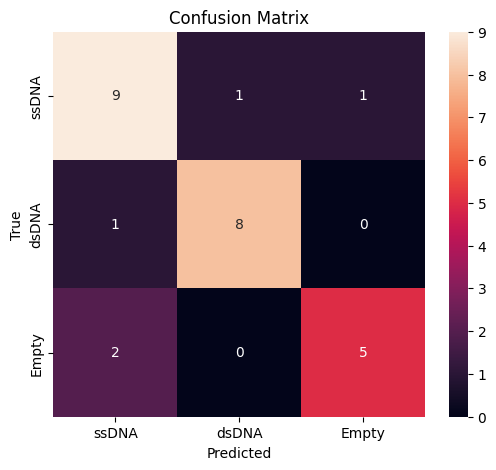

In [ ]:
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_true,y_pred)

class_names=['ssDNA','dsDNA','Empty']

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Accuracy + F1 Score
# ===============================
overall_acc = np.trace(cm)/np.sum(cm)*100

f1 = f1_score(y_true,y_pred,average='macro')

per_class_acc = cm.diagonal()/cm.sum(axis=1)*100

print("\nResults Table\n")

print(f"{'Applied Voltages':<12} {'Model':<18} {'ssDNA':<10} {'dsDNA':<10} {'Empty':<10} {'Accuracy':<10} {'F1 Score'}")

print(f"{'100 mV':<12} {'VGG19 Integrated FM':<18} "
      f"{per_class_acc[0]:.2f} "
      f"{per_class_acc[1]:.2f} "
      f"{per_class_acc[2]:.2f} "
      f"{overall_acc:.2f} "
      f"{f1:.4f}")


Results Table

Applied Voltages Model              ssDNA      dsDNA      Empty      Accuracy   F1 Score
100 mV       VGG19 Integrated FM 81.82 88.89 71.43 81.48 0.8136
